# Orange County Analysis

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Import statements
import pandas as pd
import src.analysis_utils as analysis_utils
import src.table_utils as table_utils
import src.visualization_utils as visualization_utils

# Display all columns
pd.set_option('display.max_columns', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Import Data

In [2]:
# Load in policing data
original_policing = pd.read_csv("../data/processed/cleaned_orange_ripa_2022_2024.csv", low_memory=False)

# Select only relevant columns to use
keep_cols = [
    "doj_record_id",
    "person_number",
    "agency_ori",
    "agency_name",
    "time_of_stop",
    "date_of_stop",
    "year",
    "stop_duration",
    "closest_city",
    "race_ethnicity",
    "gender",
    "age",
    "reason_for_contact",
    "traffic_violation_cjis_offense_code",
    "suspicion_cjis_offense_code",
    "suspicion",
    "action_any_search",
    "search_basis_plain_view",
    "search_basis_plain_smell",
    "search_basis_consent",
    "search_basis_safety",
    "search_basis_suspect_weapon",
    "search_basis_evidence_of_crime",
    "search_basis_school_policy",
    "search_basis_emergency",
    "search_basis_canine",
    "search_basis_warrant",
    "search_basis_probation",
    "search_basis_incident_to_arrest",
    "search_basis_vehicle_inventory",
    "contraband_any",
    "result_of_stop_arrest",
    "search_type",
    "multi_person_stop"
]
policing = original_policing[[c for c in keep_cols if c in original_policing.columns]].copy()

In [3]:
# Load in prosecution data
prosecution = pd.read_csv("https://raw.githubusercontent.com/laurenbchu/honors-thesis/main/data/processed/cleaned_orange_aclu_2021_2023.csv", low_memory=False)
prosecution['filed_date'] = pd.to_datetime(prosecution["filed_date"])
prosecution['Year'] = prosecution['filed_date'].dt.year

In [4]:
# Load in census data
census = analysis_utils.load_census("06059")

# Roll-up census data to be more coarse to match policing/prosecution race categories
census_coarse = analysis_utils.census_rollup(census)

# Policing Analysis: Stop Rates, Search Rates, and Hit Rates

In [5]:
# Filter for only discretionary stops
policing = policing[policing["reason_for_contact"].isin([
    "Moving violation",
    "Equipment violation",
    "Non-moving violation",
    "Suspect criminal activity"
])].copy()

# Add standardized race column to match policing and prosecution labels
policing = analysis_utils.add_standardized_race(policing, "race_ethnicity")

# Consider only purely discretionary searches in search and hit rates

# Clean contraband_any (handles NaN, 0/1, True/False)
policing["contraband_any"] = policing["contraband_any"].fillna(0).astype(int)

# Create discretionary search indicator
policing["disc_search"] = policing["action_any_search"] & policing["search_type"].eq("Discretionary only")

# Create hits among discretionary searches indicator
# Hits only count as hits if they were found in a search, and the search was discretionary
policing["disc_hit"] = (
    policing["disc_search"] & # Has to be from a discretionary search
    policing["action_any_search"].fillna(False) & # Has to have been searched
    (policing["contraband_any"] == 1)
)

# Create a copy with all people involved in stops for sensitivity analysis
policing_multi = policing.copy()

# Filter for person 1 for each stop (usually, the main person stopped, but not always)
policing = policing[policing["person_number"] == 1].copy()

policing_analysis = analysis_utils.policing_rates(policing, census_coarse)

In [6]:
# Creating tables
race_order = ["Black/African American", "Hispanic/Latino", "White", "Asian", "Other"]

df = policing_analysis.copy()

pop = (df[["Perceived Race", "Population"]]
       .drop_duplicates("Perceived Race")
       .set_index("Perceived Race")
       .reindex(race_order))

stops_1k = table_utils.make_pivot_with_ci(df, "Stops per 1,000", "Stops per 1,000 SE")
searches_1k = table_utils.make_pivot_with_ci(df, "Searches per 1,000", "Searches per 1,000 SE")

In [7]:
table1 = pd.concat(
    [pop, stops_1k, searches_1k],
    axis=1,
    keys=["Population", "Stops per 1,000", "Searches per 1,000"]
)


table1.columns = pd.MultiIndex.from_tuples(
    [(g, c) for g, c in table1.columns],
    names=["", "Year"]
)

table1
# export_stops_searches_to_latex(policing_analysis)

Population Stops per 1,000                  \
Year                   Population            2022            2023   
Perceived Race                                                      
Black/African American      49304  176.88 (±3.71)  158.14 (±3.51)   
Hispanic/Latino           1086834   65.75 (±0.48)   58.48 (±0.45)   
White                     1198655   52.00 (±0.41)   44.19 (±0.38)   
Asian                      699124   28.52 (±0.40)   26.03 (±0.38)   
Other                      153072   69.77 (±1.32)   61.83 (±1.25)   

                                       Searches per 1,000                 \
Year                              2024               2022           2023   
Perceived Race                                                             
Black/African American  180.70 (±3.75)      16.33 (±1.13)  13.49 (±1.03)   
Hispanic/Latino          71.35 (±0.50)       5.89 (±0.14)   5.41 (±0.14)   
White                    51.89 (±0.41)       3.12 (±0.10)   2.47 (±0.09)   
Asian                    29.96 (±0.41)       0.73 (±0.06)   0.67 (±0.06)   
Other                    80.77 (±1.42)       1.91 (±0.22)   1.57 (±0.20)   

                                       
Year                             2024  
Perceived Race                         
Black/African American  15.76 (±1.11)  
Hispanic/Latino          7.06 (±0.16)  
White                    3.02 (±0.10)  
Asian                    0.71 (±0.06)  
Other                    2.44 (±0.25)

In [8]:
tab2 = df.copy()

# Convert proportions to percentages
tab2["Search Rate"] *= 100
tab2["Hit Rate"] *= 100
tab2["Search Rate SE"] *= 100
tab2["Hit Rate SE"] *= 100

search_rate = table_utils.make_pivot_with_ci(tab2, "Search Rate", "Search Rate SE")
hit_rate = table_utils.make_pivot_with_ci(tab2, "Hit Rate", "Hit Rate SE")

table2 = pd.concat([search_rate, hit_rate], axis=1, keys=["Search Rate (%)", "Hit Rate (%)"])

table2.columns = pd.MultiIndex.from_tuples(
    [(g, c) for g, c in table2.columns],
    names=["", "Year"]
)

table2 = table2.reindex(race_order)
table2
# export_searches_hits_to_latex(policing_analysis)

Search Rate (%)                              \
Year                              2022          2023          2024   
Perceived Race                                                       
Black/African American    9.23 (±0.61)  8.53 (±0.62)  8.72 (±0.59)   
Hispanic/Latino           8.96 (±0.21)  9.25 (±0.23)  9.89 (±0.21)   
White                     6.01 (±0.19)  5.58 (±0.20)  5.81 (±0.18)   
Asian                     2.57 (±0.22)  2.59 (±0.23)  2.37 (±0.21)   
Other                     2.74 (±0.31)  2.55 (±0.32)  3.02 (±0.30)   

                         Hit Rate (%)                                
Year                             2022           2023           2024  
Perceived Race                                                       
Black/African American  29.19 (±3.14)  25.11 (±3.30)  24.58 (±3.03)  
Hispanic/Latino         30.72 (±1.13)  27.52 (±1.14)  25.60 (±0.98)  
White                   37.06 (±1.55)  37.62 (±1.75)  33.91 (±1.54)  
Asian                   31.97 (±4.04)  30.36 (±4.15)  30.78 (±4.06)  
Other                   29.01 (±5.20)  23.65 (±5.37)  25.94 (±4.44)

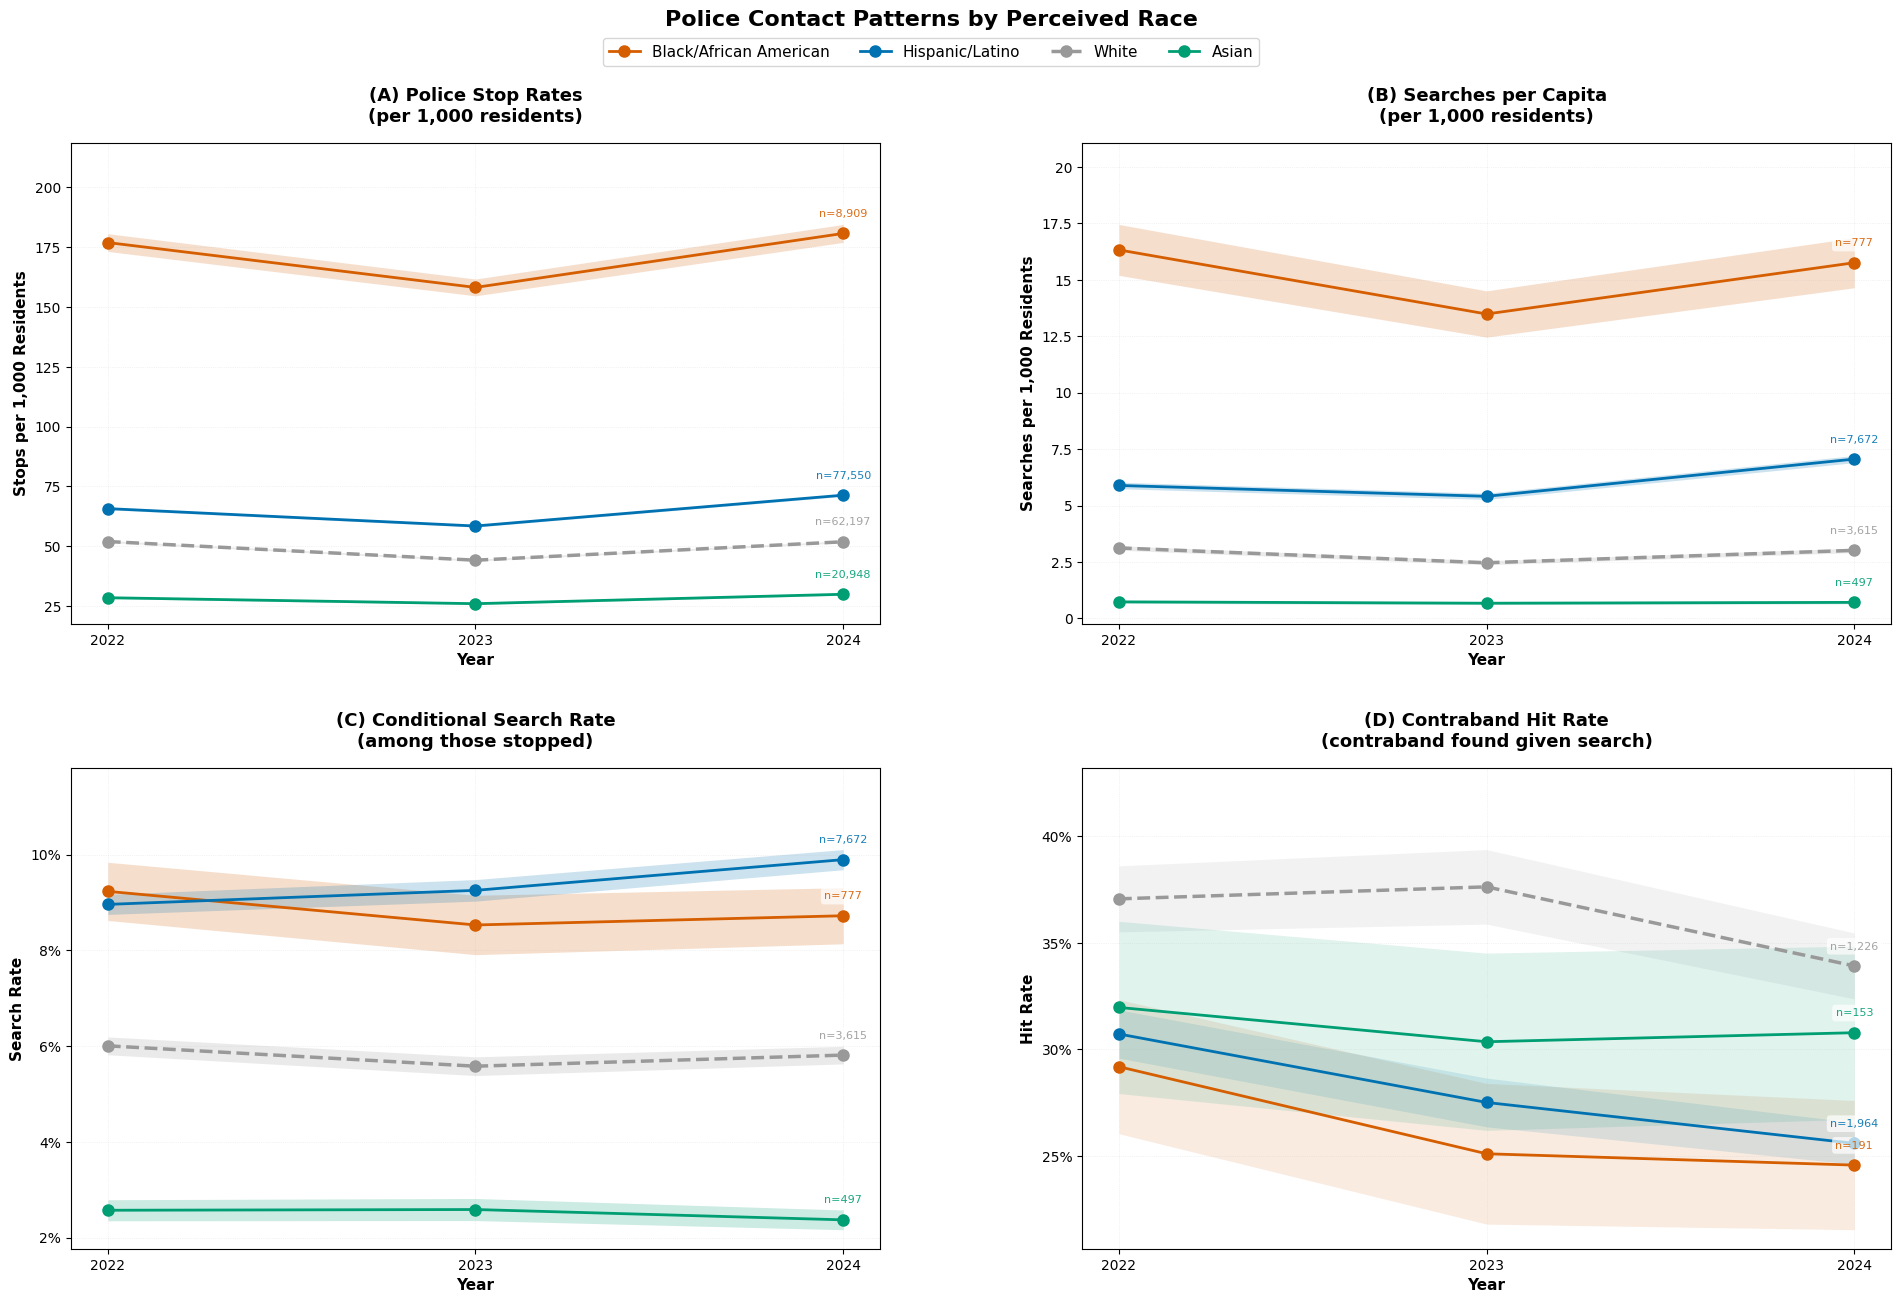

In [9]:
policing_figs = visualization_utils.visualize_policing(policing_analysis)
# visualization_utils.export_figure_to_pdf(policing_figs, "policing")

# Policing Analysis: Stratified by Reason for Contact

In [10]:
# Calculate rates by reason for contact
policing_by_reason = analysis_utils.policing_rates_by_reason_for_contact(policing, census_coarse)

# Create comprehensive table with pooled 2022-2024 data
reason_table = table_utils.create_reason_for_contact_table(policing_by_reason)
display(reason_table)
# table_utils.export_reason_for_contact_table_to_latex(reason_table)

,Reason for Contact,Perceived Race,Stops,Searches,Search Rate (%),Hit Rate (%)
0,Moving violation,Black/African American,9754,323,3.31 (±0.36),18.27 (±4.21)
1,,Hispanic/Latino,93087,4782,5.14 (±0.14),17.04 (±1.07)
2,,White,97652,1586,1.62 (±0.08),28.06 (±2.21)
3,,Asian,38581,300,0.78 (±0.09),22.67 (±4.74)
4,,Other,21428,202,0.94 (±0.13),19.31 (±5.44)
5,Equipment violation,Black/African American,7054,615,8.72 (±0.66),20.98 (±3.22)
6,,Hispanic/Latino,62378,5943,9.53 (±0.23),25.81 (±1.11)
7,,White,33380,2560,7.67 (±0.29),35.23 (±1.85)
8,,Asian,9761,394,4.04 (±0.39),31.22 (±4.58)
9,,Other,5826,247,4.24 (±0.52),25.10 (±5.41)


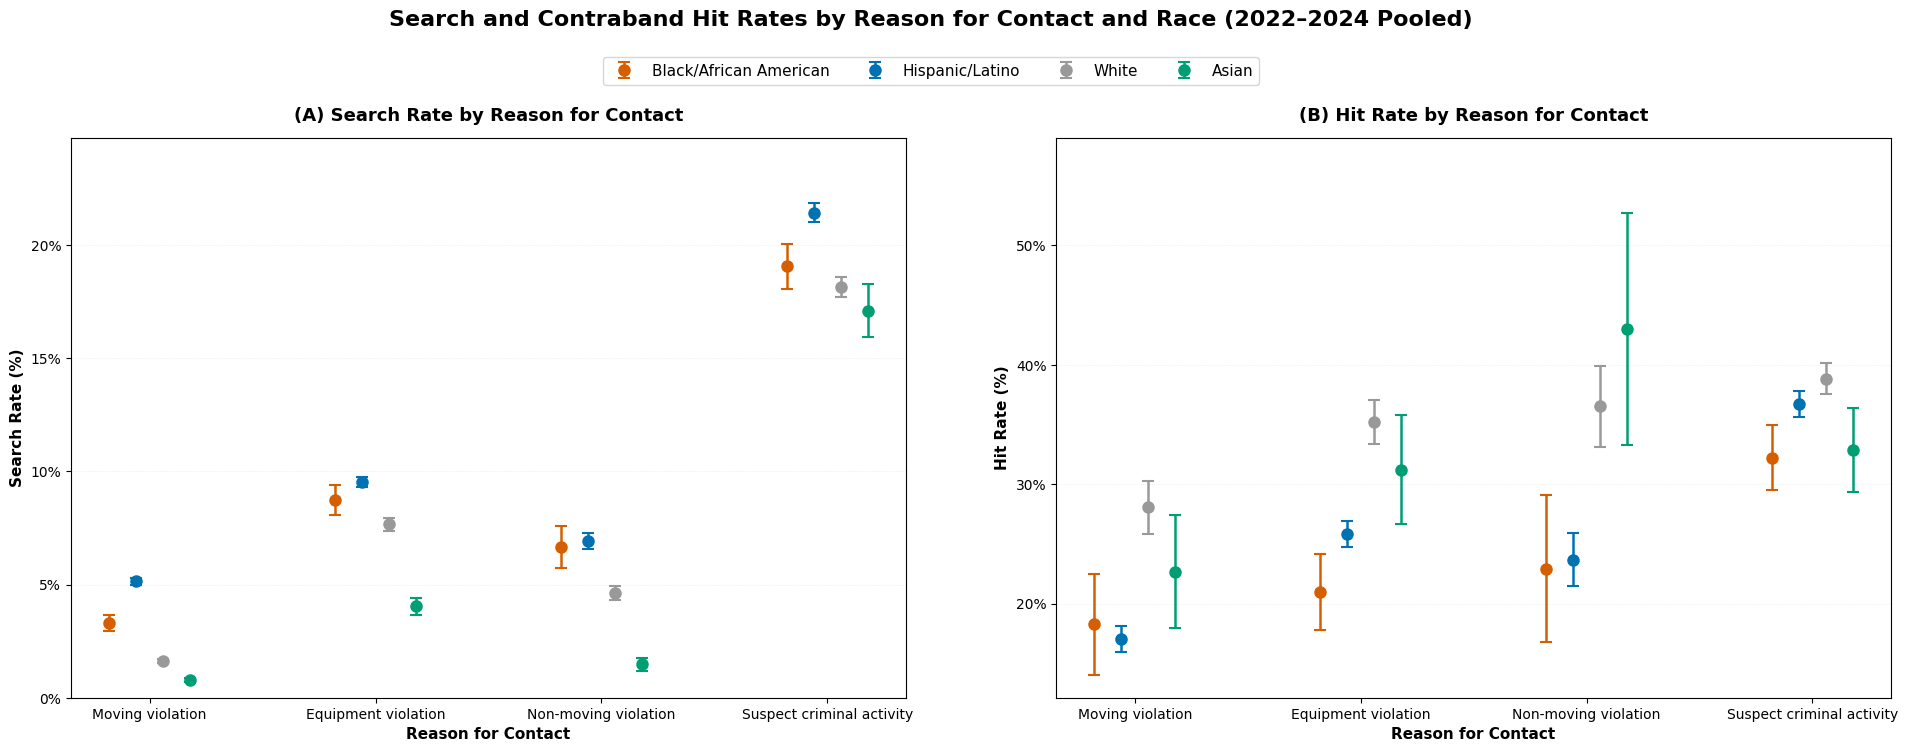

In [11]:
# Create search rate visualization
fig_search = visualization_utils.visualize_search_and_hit_rates_by_reason(policing_by_reason)
# visualization_utils.export_figure_to_pdf(fig_search, "policing_by_reason")

# Policing Analysis: Black and White Hit Rates by Agency

In [12]:
# Calculate the White and Black hit rates for each agency and summarize in a table
agency_hit_summary = analysis_utils.summarize_agency_black_white_hit_rates(policing)
publication_table = table_utils.agency_black_white_hit_rate_table(agency_hit_summary)
publication_table
# table_utils.export_agency_hit_rates_to_latex(agency_hit_summary)

,Agency Name,White Search Count,White Hit Count,White Hit Rate,Black Search Count,Black Hit Count,Black Hit Rate
0,Anaheim PD,1248,448,35.90,328,80,24.39
1,Brea PD,219,94,42.92,67,28,41.79
2,Buena Park PD,261,79,30.27,142,33,23.24
3,Cal State Fullerton PD,38,23,60.53,9,2,22.22
4,Costa Mesa PD,463,233,50.32,77,24,31.17
5,Cypress PD,111,54,48.65,43,17,39.53
6,Fountain Valley PD,137,66,48.18,23,15,65.22
7,Fullerton PD,680,236,34.71,223,59,26.46
8,Garden Grove PD,142,61,42.96,41,20,48.78
9,Huntington Beach PD,574,221,38.50,53,18,33.96


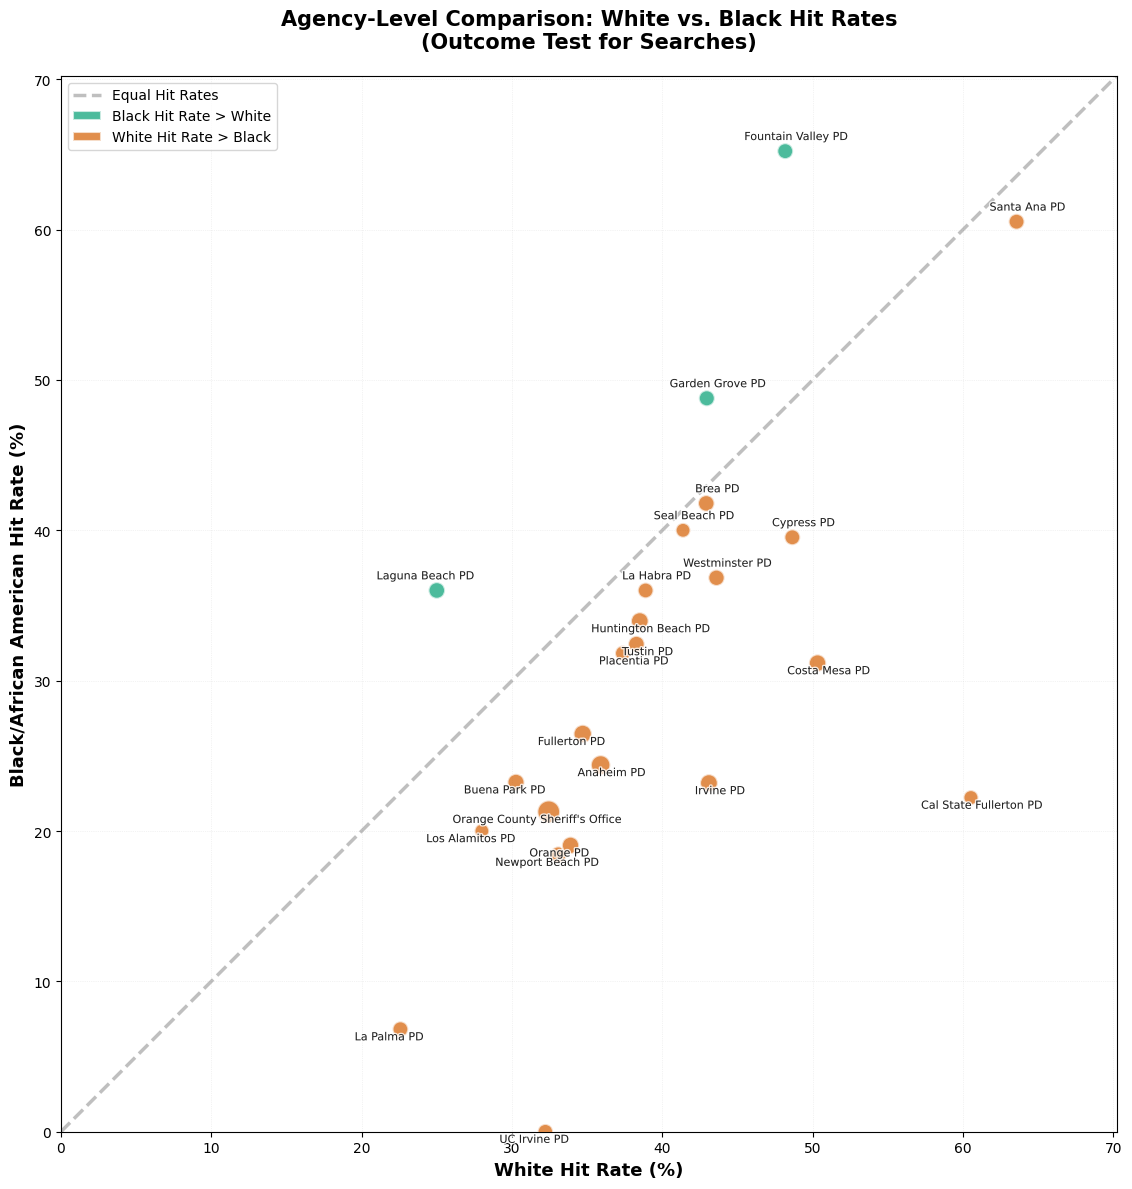

In [13]:
fig_agency_hit = visualization_utils.plot_agency_black_white_hit_rates(agency_hit_summary)
# visualization_utils.export_figure_to_pdf(fig_agency_hit, "agency_hits")

# Policing Sensitivity Analysis: Mixed Search Bases and Multiperson Stops

In [14]:
# Checks sensitivity of search and hit rates to including searches with mixed legal bases (e.g. "Mixed" or "No search basis") as discretionary searches

policing["disc_search_mixed"] = (
    policing["action_any_search"]
    & policing["search_type"].isin(["Discretionary only", "Mixed", "No search basis"])
)

policing["disc_hit_mixed"] = (
    policing["disc_search_mixed"]
    & policing["action_any_search"].fillna(False)
    & (policing["contraband_any"] == 1)
)

policing_analysis_mixed = analysis_utils.policing_rates_sensitivity(
    policing,
    census_coarse,
    "mixed"
)

# Checks sensitivity of search and hit rates to including all people involved in stops (not just person 1) for multiperson stops

policing_multi.rename(
    columns={"disc_search": "disc_search_multiperson"},
    inplace=True
)

policing_multi["disc_hit_multiperson"] = (
    policing_multi["disc_search_multiperson"]
    & policing_multi["action_any_search"].fillna(False)
    & (policing_multi["contraband_any"] == 1)
)

policing_analysis_multiperson = analysis_utils.policing_rates_sensitivity(
    policing_multi,
    census_coarse,
    "multiperson"
)

In [15]:
# Creates one table for 2024

def make_2024_block(df, label):
    """Return a 2024 table with formatted Search/Hit rates for one method."""
    d = df[df["Year"] == 2024].copy()
    d = d.set_index("Perceived Race")

    def special_fmt_est_ci(rate, se, digits=2):
        pct = rate * 100
        ci = 1.96 * se * 100
        return f"{pct:.{digits}f} (±{ci:.{digits}f})"

    out = pd.DataFrame(index=d.index)
    out[("Search Rate (%)", label)] = [
        special_fmt_est_ci(e, s, 2)
        for e, s in zip(d["Search Rate"], d["Search Rate SE"])
    ]
    out[("Hit Rate (%)", label)] = [
        special_fmt_est_ci(e, s, 2)
        for e, s in zip(d["Hit Rate"], d["Hit Rate SE"])
    ]
    return out

# Build 2024 display blocks
baseline_2024 = make_2024_block(policing_analysis.copy(), "Baseline")
mixed_2024 = make_2024_block(policing_analysis_mixed.copy(), "Mixed")
multiperson_2024 = make_2024_block(policing_analysis_multiperson.copy(), "Multiperson")

# Join into one combined display table
table3 = baseline_2024.join(mixed_2024, how="outer").join(multiperson_2024, how="outer")

# Enforce row order
race_order = ["Black/African American", "Hispanic/Latino", "White", "Asian", "Other"]
table3 = table3.reindex(race_order)

# Enforce column order
table3 = table3[
    [
        ("Search Rate (%)", "Baseline"),
        ("Search Rate (%)", "Mixed"),
        ("Search Rate (%)", "Multiperson"),
        ("Hit Rate (%)", "Baseline"),
        ("Hit Rate (%)", "Mixed"),
        ("Hit Rate (%)", "Multiperson"),
    ]
]

table3.columns = pd.MultiIndex.from_tuples(table3.columns, names=["", ""])
table3.index.name = "Perceived Race"

table3
# export_combined_sensitivity_to_latex(policing_analysis, policing_analysis_mixed, policing_analysis_multiperson)

Search Rate (%)                                \
                              Baseline          Mixed    Multiperson   
Perceived Race                                                         
Black/African American    8.72 (±0.59)  12.46 (±0.69)   9.40 (±0.58)   
Hispanic/Latino           9.89 (±0.21)  13.15 (±0.24)  10.80 (±0.21)   
White                     5.81 (±0.18)   8.09 (±0.21)   6.55 (±0.19)   
Asian                     2.37 (±0.21)   3.13 (±0.24)   2.52 (±0.21)   
Other                     3.02 (±0.30)   3.92 (±0.34)   3.33 (±0.31)   

                         Hit Rate (%)                                
                             Baseline          Mixed    Multiperson  
Perceived Race                                                       
Black/African American  24.58 (±3.03)  28.92 (±2.67)  24.67 (±2.80)  
Hispanic/Latino         25.60 (±0.98)  30.50 (±0.89)  26.16 (±0.90)  
White                   33.91 (±1.54)  38.79 (±1.35)  34.12 (±1.41)  
Asian                   30.78 (±4.06)  35.06 (±3.65)  30.47 (±3.82)  
Other                   25.94 (±4.44)  27.63 (±3.98)  26.05 (±4.15)

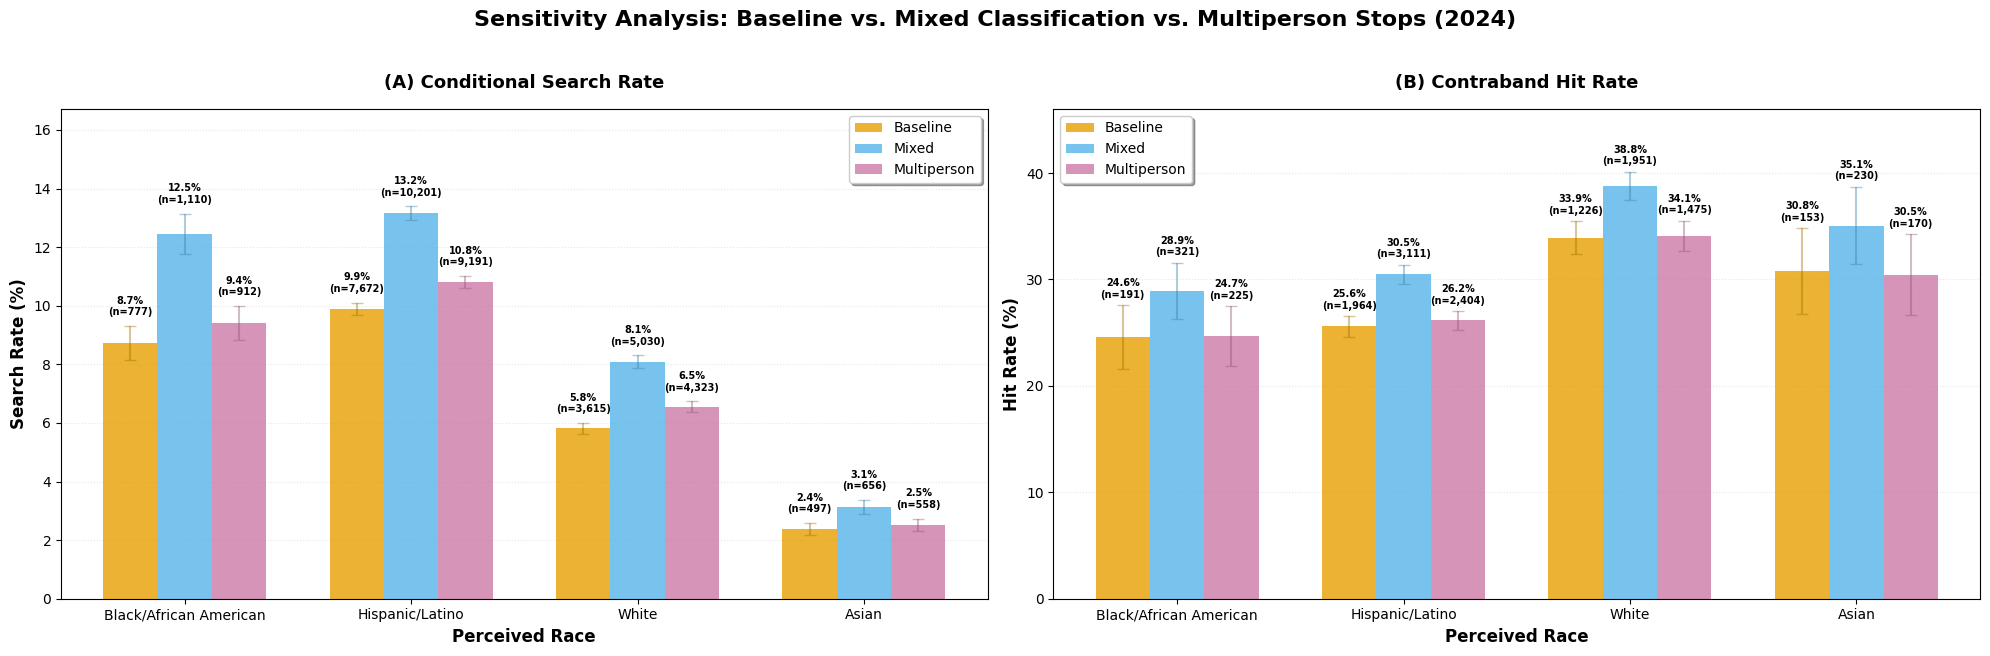

In [16]:
sensitivity_fig = visualization_utils.create_combined_sensitivity_visualization(
    policing_analysis,
    policing_analysis_mixed,
    policing_analysis_multiperson
)

# visualization_utils.export_figure_to_pdf(sensitivity_fig, "sensitivity")

# Prosecution Analysis: Enhancement Rates by Charge and Statute Level

In [17]:
# Harmonizes race labels
prosecution = analysis_utils.add_standardized_race(prosecution, 'canonical_race')

# Identify charges that are enhancements/priors/sentencing considerations rather than actual substantive criminal charges
prosecution['is_non_substantive'] = (
    prosecution['is_enhancement_charge'].astype(bool) |
    prosecution['is_special_circumstance'].astype(bool) |
    prosecution['is_sentencing_charge'].astype(bool)
)

# Apply categorization ONLY to substantive charges
prosecution.loc[~prosecution['is_non_substantive'], 'charge_category'] = \
    prosecution.loc[~prosecution['is_non_substantive'], 'charge_description'].apply(analysis_utils.categorize_charge)

# For non-substantive charges, label them explicitly as ehancement/prior/sentencing
prosecution.loc[prosecution['is_non_substantive'], 'charge_category'] = 'Enhancement/Prior/Sentencing'

# Each case is a single defendant, so case-level = defendant-case-level
# For each case, if any charge is an enhancement charge, then the case is flagged as having an enhancement charge
enh_flag = (
    prosecution.groupby('source_case_id')['is_enhancement_charge']
    .max()
    .rename('any_enhancement_in_case')
    .reset_index()
)

# Drop the enhancement rows, keeping only the base charges
substantive = prosecution[~prosecution['is_non_substantive']].copy()

# Add the enhancement flag to the dataframe
substantive = substantive.merge(enh_flag, on='source_case_id', how='left')
substantive['any_enhancement_in_case'] = substantive['any_enhancement_in_case'].fillna(0).astype(int)

# Calculate enhancement rates by charge category
# For each case, a primary charge category and statute level is assigned
# Then computes cases with any enhancement charge over total cases for each charge category
enhancement_by_primary = analysis_utils.enhancement_rates_by_primary_severity(substantive)

# Calculate and display average enhancement rates by primary charge category
enhancement_by_primary.groupby("primary_charge_category").apply(lambda g: g["Enhanced"].sum() / g["N"].sum()).sort_values(ascending=False)

# Excludes the "Other" category and categories with less than a 5% average enhancement rate across all races and statute levels
filtered_enhancement = enhancement_by_primary[
    enhancement_by_primary["primary_charge_category"].isin(
        enhancement_by_primary.groupby("primary_charge_category")
        .apply(lambda g: g["Enhanced"].sum() / g["N"].sum())
        .loc[lambda s: (s >= 0.05) & (s.index != "Other")]
        .index
    )
].copy()

In [18]:
# Table 1: By race and statute level
enhancement_combined = table_utils.enhancement_rate_combined_table(enhancement_by_primary)
display(enhancement_combined)

# Table 2: By race, statute level, and primary category (for all categories)
# Excludes the "Other" category and categories with less than a 5% overall enhancement rate
enhancement_category = table_utils.enhancement_rate_race_statute_category_table(filtered_enhancement)
display(enhancement_category)

# export_enhancement_tables_to_latex(enhancement_combined, enhancement_category)

,Canonical Race,Statute Level,Number of Cases,Enhancement Rate (%)
0,Black/African American,Overall,4292,18.31 (±1.16)
1,,Misdemeanor,3119,22.54 (±1.47)
2,,Felony,1173,7.08 (±1.47)
3,Hispanic/Latino,Overall,39521,22.31 (±0.41)
4,,Misdemeanor,31878,25.86 (±0.48)
5,,Felony,7643,7.50 (±0.59)
6,White,Overall,29903,17.89 (±0.43)
7,,Misdemeanor,25136,20.44 (±0.50)
8,,Felony,4767,4.45 (±0.59)
9,Asian,Overall,3809,25.31 (±1.38)


,Charge Category,Canonical Race,Statute Level,Number of Cases,Enhancement Rate (%)
0,DUI,Black/African American,Misdemeanor,700,93.14 (±1.87)
1,,,Felony,19,73.68 (±19.80)
2,,Hispanic/Latino,Misdemeanor,8225,94.38 (±0.50)
3,,,Felony,249,58.23 (±6.13)
4,,White,Misdemeanor,5299,91.72 (±0.74)
5,,,Felony,139,45.32 (±8.28)
6,,Asian,Misdemeanor,952,94.54 (±1.44)
7,,,Felony,10,50.00 (±30.99)
8,,Other,Misdemeanor,823,92.83 (±1.76)
9,,,Felony,17,35.29 (±22.72)


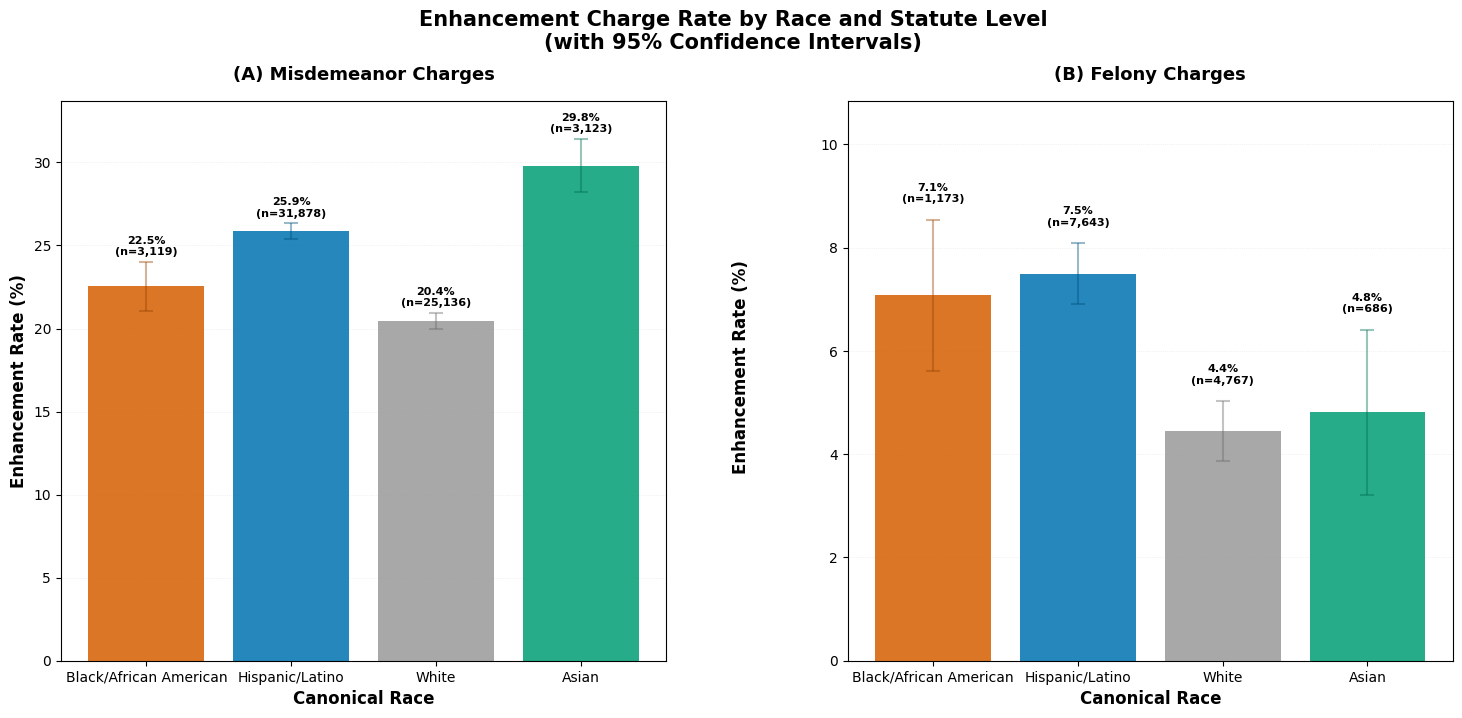

In [19]:
# Plot: By race and statute level

without_other = enhancement_by_primary[enhancement_by_primary["race_std"] != "Other"].copy()
enhancement_rate_race_statute = visualization_utils.plot_enhancement_rate_by_race_statute(without_other)
# visualization_utils.export_figure_to_pdf(enhancement_rate_race_statute, "enhancement_rate_by_race_statute")

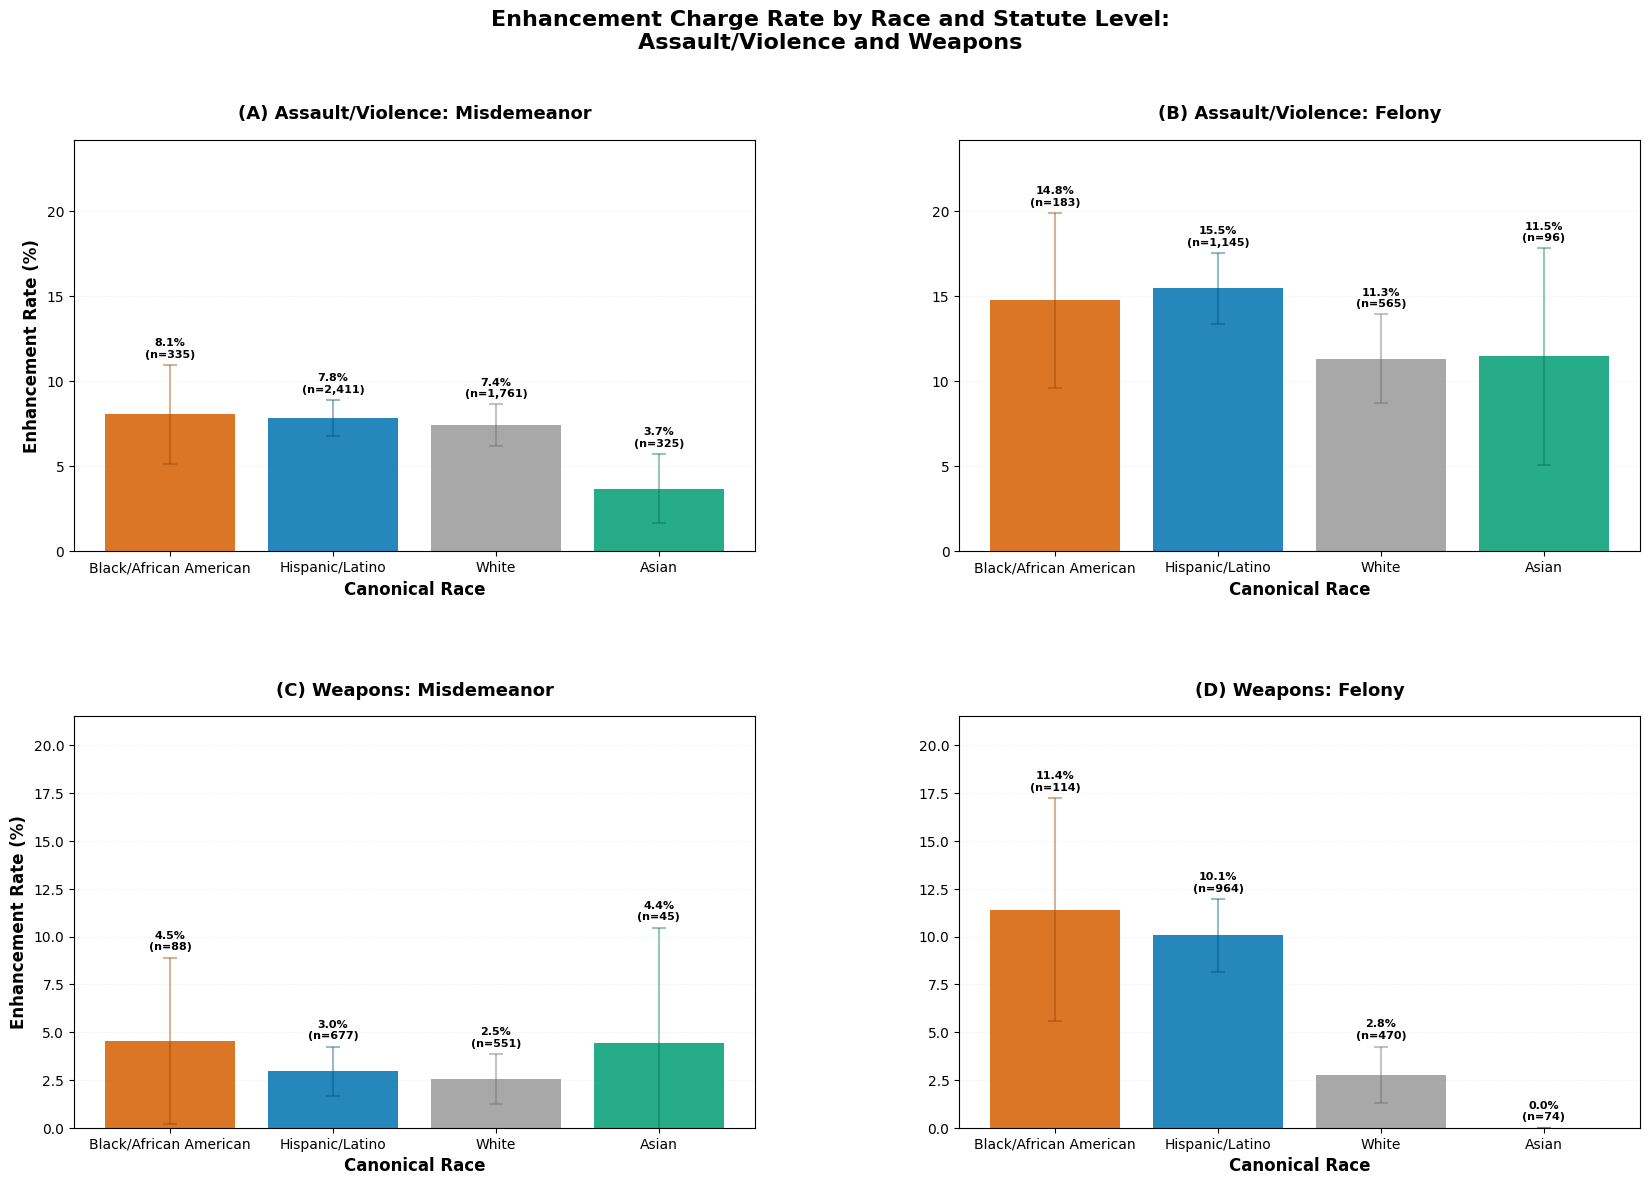

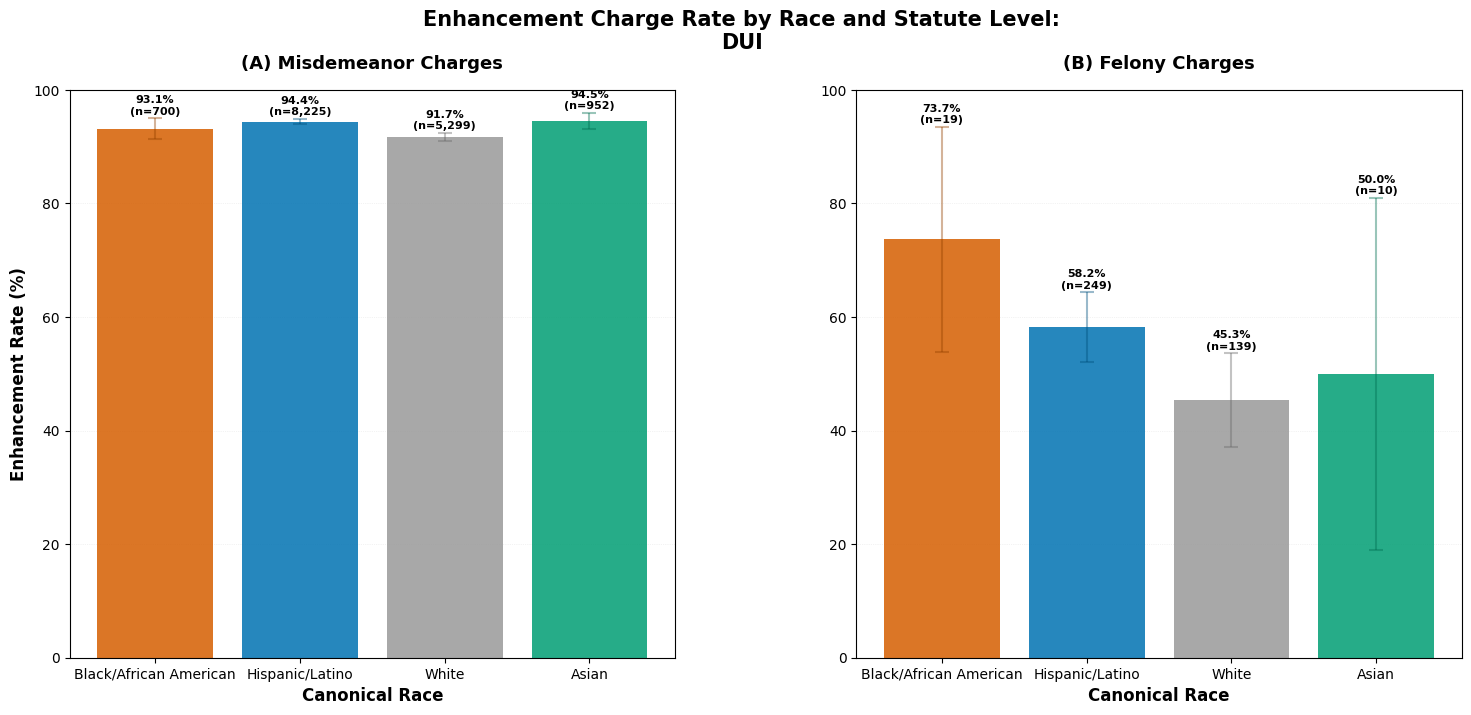

In [20]:
figs = visualization_utils.plot_enhancement_rate_by_race_statute_category(enhancement_by_primary)
# visualization_utils.export_figure_to_pdf(figs["assault_violence_weapons"], "enhancement_assault_violence_weapons")
# visualization_utils.export_figure_to_pdf(figs["dui"], "enhancement_dui")

# Prosecution Analysis: Wobblers

In [21]:
filtered_wobbler_categories = analysis_utils.get_filtered_wobbler_categories(substantive)
wobbler_table, wobbler_category_table = table_utils.wobbler_felony_rate_tables(substantive)

display(wobbler_table)

# For the category table, we only display categories with at least 5% overall wobbler felony filing rate and total wobbler cases of at least 500
# Also exclude "Other" category
display(wobbler_category_table)

# export_wobbler_tables_to_latex(wobbler_table, wobbler_category_table)

,Total Wobblers,Filed as Felony,Filed as Misdemeanor,Felony Rate (%) [95% CI]
Canonical Race,,,,
Black/African American,5684,2927,2757,51.5 (±1.3)
Hispanic/Latino,49976,21438,28538,42.9 (±0.4)
White,35432,11179,24253,31.6 (±0.5)
Asian,4517,1912,2605,42.3 (±1.4)
Other,4532,2124,2408,46.9 (±1.5)


Total Wobblers  \
Charge Category           Canonical Race                           
Theft/Burglary/Robbery    Black/African American            1659   
                          Hispanic/Latino                  11065   
                          White                             5890   
                          Asian                              834   
                          Other                              752   
Assault/Violence          Black/African American             838   
                          Hispanic/Latino                   5395   
                          White                             2736   
                          Asian                              485   
                          Other                              361   
Fraud/Identity Theft      Black/African American             296   
                          Hispanic/Latino                   2398   
                          White                             2493   
                          Asian                              472   
                          Other                              961   
Weapons                   Black/African American             289   
                          Hispanic/Latino                   2857   
                          White                             1407   
                          Asian                              214   
                          Other                              133   
Vandalism                 Black/African American             244   
                          Hispanic/Latino                   2196   
                          White                             1166   
                          Asian                              215   
                          Other                              162   
Vehicle-Related (non-DUI) Black/African American              77   
                          Hispanic/Latino                    790   
                          White                              360   
                          Asian                               34   
                          Other                               90   
Obstruct/Resist Officer   Black/African American             134   
                          Hispanic/Latino                    699   
                          White                              350   
                          Asian                               51   
                          Other                               57   

                                                  Filed as Felony  \
Charge Category           Canonical Race                            
Theft/Burglary/Robbery    Black/African American             1406   
                          Hispanic/Latino                    9271   
                          White                              4520   
                          Asian                               686   
                          Other                               587   
Assault/Violence          Black/African American              494   
                          Hispanic/Latino                    3388   
                          White                              1337   
                          Asian                               254   
                          Other                               166   
Fraud/Identity Theft      Black/African American              265   
                          Hispanic/Latino                    2163   
                          White                              2274   
                          Asian                               434   
                          Other                               930   
Weapons                   Black/African American              214   
                          Hispanic/Latino                    2232   
                          White                               889   
                          Asian                               174   
                          Other                                87   
Vandalism      

c:\Thesis\honors-thesis\src\visualization_utils.py:1476: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.99])


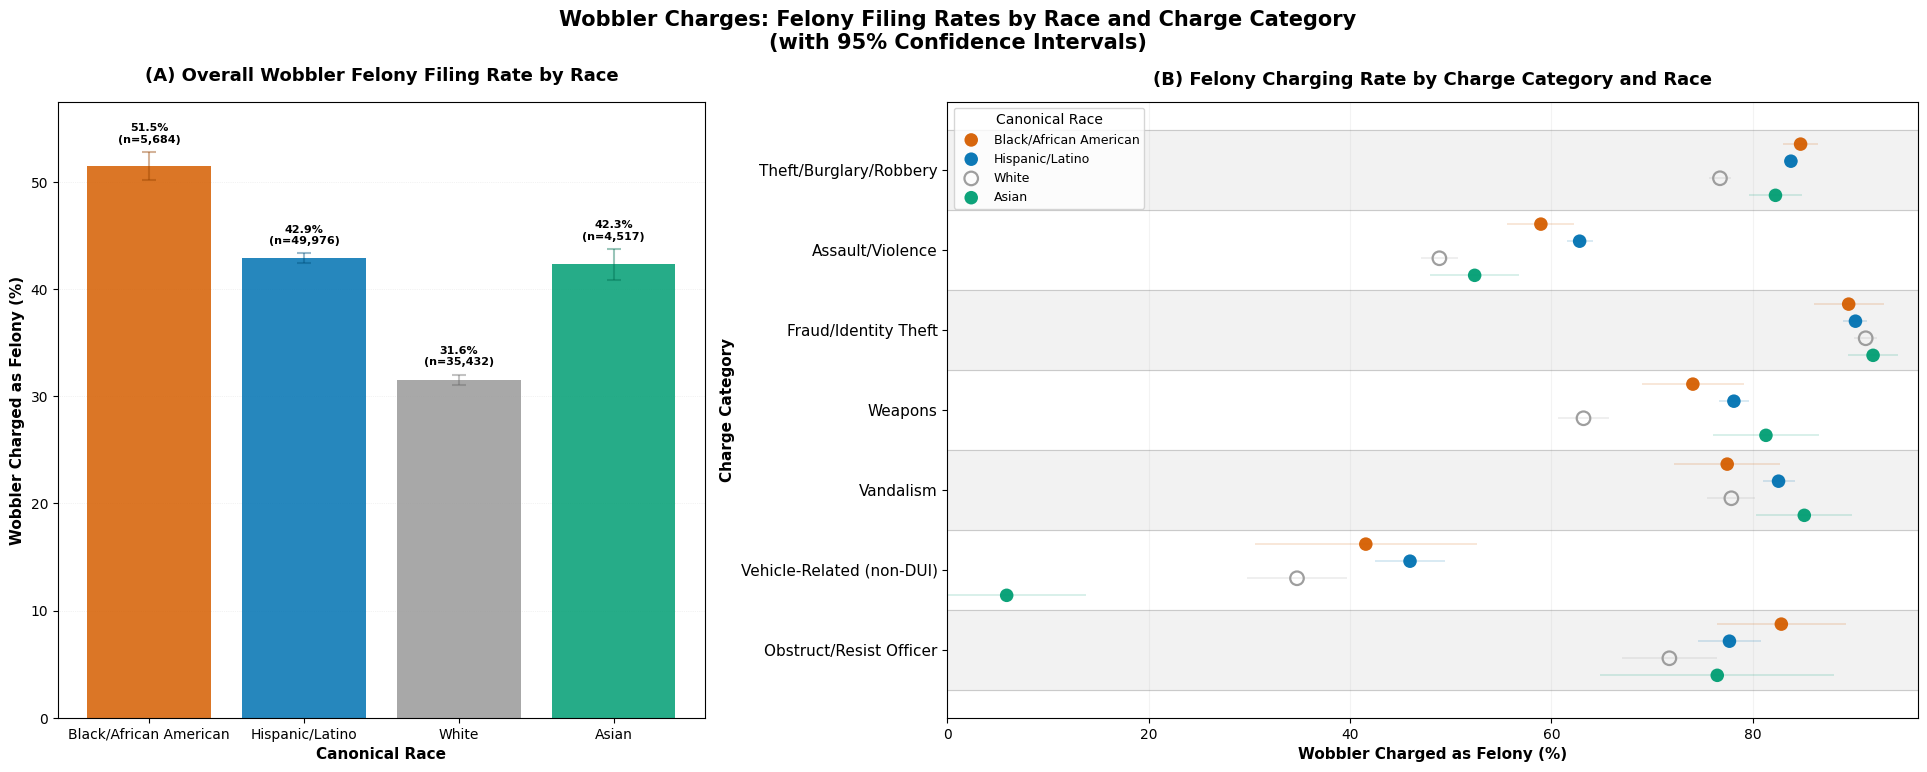

In [22]:
fig = visualization_utils.plot_wobbler_combined(substantive, top_categories=filtered_wobbler_categories, sort_by="rate_overall")
# visualization_utils.export_figure_to_pdf(fig, "wobblers")